# 02. Análisis Exploratorio de Datos (EDA)
Este cuaderno tiene como objetivo analizar las características estadísticas del conjunto de datos unificado de transacciones para fundamentar las decisiones de diseño del modelo de recomendación Two Towers (Dual Encoder).


In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurar estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]


## 1. Cargar Datos
Cargamos los datos procesados en el paso anterior.


In [2]:
txs = pl.read_parquet("data_processed/transactions_unified.parquet")
prd = pl.read_parquet("data_processed/products_catalog.parquet")

print(f"Transacciones cargadas: {txs.height} filas, {txs.width} columnas.")
print(f"Productos cargados: {prd.height} filas, {prd.width} columnas.")


Transacciones cargadas: 5876800 filas, 39 columnas.
Productos cargados: 20684 filas, 14 columnas.


## 2. Estadísticas de Sparsity e Interacciones
El modelo Two Towers calcula embeddings latentes a partir de una matriz de interacciones de usuario y producto. Evaluemos la esparcidad de esta matriz.


In [3]:
num_clients = txs.select("RUC").n_unique()
num_products = txs.select("COD_PROD").n_unique()
num_interactions = txs.select(["RUC", "COD_PROD"]).unique().height

sparsity = 1.0 - (num_interactions / (num_clients * num_products))

print(f"Clientes únicos (RUC): {num_clients}")
print(f"Productos con interacciones: {num_products}")
print(f"Pares cliente-producto únicos interactuados: {num_interactions}")
print(f"Sparsity de la matriz de interacción: {sparsity * 100:.4f}%")


Clientes únicos (RUC): 14935
Productos con interacciones: 13840
Pares cliente-producto únicos interactuados: 2518215
Sparsity de la matriz de interacción: 98.7817%


## 3. Análisis de Datos Faltantes (Missing Values)
Analicemos la cantidad de valores nulos en columnas críticas de transacciones y catálogo.


In [4]:
# Nulos en transacciones
nulls_txs = txs.null_count()
nulls_pct_txs = (nulls_txs / txs.height) * 100

print("Valores nulos en transacciones (%):")
for col in txs.columns:
    pct = nulls_pct_txs[col][0]
    if pct > 0:
        print(f" - {col}: {pct:.4f}%")


Valores nulos en transacciones (%):
 - RUTA: 2.6506%
 - DIRECCION: 0.0005%
 - LONGITUD: 27.0817%
 - LATITUD: 27.0875%
 - MARCA: 5.5489%
 - GRUPO: 0.0006%
 - EAN13: 6.0875%
 - PROVEEDOR: 1.5698%
 - RUC_PROVEE: 1.9471%
 - FAMILIA1: 0.2783%
 - FAMILIA2: 0.3942%
 - FAMILIA3: 50.7974%
 - UNIDAD: 0.2095%
 - NATURALJUR: 0.4029%
 - SEXO: 0.4029%
 - ESTADOCIVI: 0.4029%
 - ORIGENINGR: 0.4029%


In [5]:
# Nulos en catálogo
nulls_prd = prd.null_count()
nulls_pct_prd = (nulls_prd / prd.height) * 100

print("Valores nulos en catálogo (%):")
for col in prd.columns:
    pct = nulls_pct_prd[col][0]
    if pct > 0:
        print(f" - {col}: {pct:.4f}%")


Valores nulos en catálogo (%):
 - categoría: 100.0000%
 - marca: 6.7975%
 - ean13: 50.4738%
 - familia1: 6.7202%
 - familia2: 7.7790%
 - familia3: 97.7180%
 - proveedor: 7.7306%
 - unidad: 5.2649%


## 4. Distribuciones de Ventas, Cantidades y Márgenes
Evaluamos las ventas totales, volúmenes comprados y la rentabilidad.


In [6]:
# Resumen estadístico básico
summary_stats = txs.select([
    pl.col("VENTA").mean().alias("venta_media"),
    pl.col("VENTA").max().alias("venta_max"),
    pl.col("CANTIDAD").mean().alias("cant_media"),
    pl.col("GANANCIA").mean().alias("ganancia_media")
])
print(summary_stats)


shape: (1, 4)
┌─────────────┬───────────┬────────────┬────────────────┐
│ venta_media ┆ venta_max ┆ cant_media ┆ ganancia_media │
│ ---         ┆ ---       ┆ ---        ┆ ---            │
│ f64         ┆ f64       ┆ f64        ┆ f64            │
╞═════════════╪═══════════╪════════════╪════════════════╡
│ 46.706709   ┆ 73031.46  ┆ 17.17328   ┆ 7.171722       │
└─────────────┴───────────┴────────────┴────────────────┘


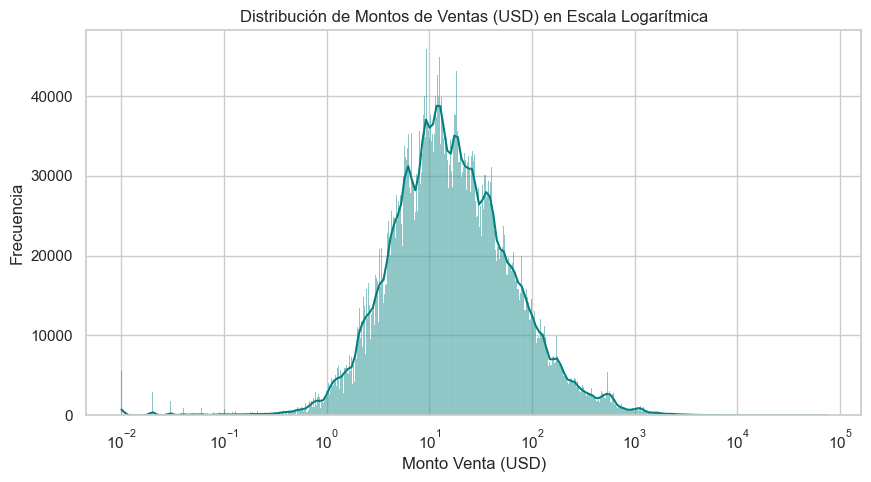

In [7]:
# Distribución de montos de venta (escala logarítmica para mejor visualización)
ventas_vals = txs.select(pl.col("VENTA").filter(pl.col("VENTA") > 0)).to_series().to_numpy()

plt.figure(figsize=(10, 5))
sns.histplot(ventas_vals, log_scale=True, kde=True, color="teal")
plt.title("Distribución de Montos de Ventas (USD) en Escala Logarítmica")
plt.xlabel("Monto Venta (USD)")
plt.ylabel("Frecuencia")
plt.savefig("distribucion_ventas.png")
plt.show()


## 5. Distribución Geográfica y Rutas de Clientes
El anteproyecto menciona que la ubicación geográfica y la ruta son características del usuario clave.


In [8]:
# Ciudades con mayor volumen de transacciones
ciudades_txs = txs.group_by("CIUDAD").agg(
    pl.len().alias("num_txs"),
    pl.col("VENTA").sum().alias("ventas_totales")
).sort("num_txs", descending=True)

print("Top 10 ciudades por transacciones:")
print(ciudades_txs.head(10))


Top 10 ciudades por transacciones:
shape: (8, 3)
┌────────┬─────────┬────────────────┐
│ CIUDAD ┆ num_txs ┆ ventas_totales │
│ ---    ┆ ---     ┆ ---            │
│ str    ┆ u32     ┆ f64            │
╞════════╪═════════╪════════════════╡
│ uio    ┆ 2732803 ┆ 8.5288e7       │
│ cue    ┆ 736290  ┆ 3.8323e7       │
│ gye    ┆ 671362  ┆ 4.7035e7       │
│ amb    ┆ 549414  ┆ 3.0403e7       │
│ man    ┆ 459393  ┆ 2.8464e7       │
│ sto    ┆ 424876  ┆ 2.7157e7       │
│ coc    ┆ 266706  ┆ 1.6237e7       │
│ mks    ┆ 35956   ┆ 1.5795e6       │
└────────┴─────────┴────────────────┘


In [9]:
# Rutas de distribución con mayor volumen
rutas_txs = txs.group_by("RUTA").agg(
    pl.len().alias("num_txs"),
    pl.col("VENTA").sum().alias("ventas_totales")
).sort("num_txs", descending=True)

print("Top 10 rutas de distribución:")
print(rutas_txs.head(10))


Top 10 rutas de distribución:
shape: (10, 3)
┌───────────────┬─────────┬────────────────┐
│ RUTA          ┆ num_txs ┆ ventas_totales │
│ ---           ┆ ---     ┆ ---            │
│ str           ┆ u32     ┆ f64            │
╞═══════════════╪═════════╪════════════════╡
│ 3 SUR 2       ┆ 438046  ┆ 1.0460e7       │
│ 2 SUR 1       ┆ 398054  ┆ 1.0080e7       │
│ 6 NORTE 2     ┆ 257346  ┆ 5.7565e6       │
│ 5 NORTE 1     ┆ 236185  ┆ 6.667515e6     │
│ SANTO DOMINGO ┆ 188634  ┆ 1.0679e7       │
│ 4 CENTRO      ┆ 181412  ┆ 6.2382e6       │
│ CUENCA SUR    ┆ 174005  ┆ 7.6849e6       │
│ NORTE         ┆ 171998  ┆ 8.4072e6       │
│ 19 TUMBACO    ┆ 171257  ┆ 7.2617e6       │
│ 7 VALLE 1     ┆ 163487  ┆ 3.4163e6       │
└───────────────┴─────────┴────────────────┘


## 6. Co-ocurrencias y Ventanas de Compra
Analizamos cuántos productos únicos suele comprar un cliente por día de transacción. Esto ayuda a definir la ventana para armar los pares de co-compra.


In [10]:
# Cantidad de productos comprados en un mismo día por cliente
items_por_dia_cliente = txs.group_by(["RUC", "FECHA"]).agg(
    pl.col("COD_PROD").n_unique().alias("num_productos")
).sort("num_productos", descending=True)

print("Estadísticas de productos por día-cliente:")
print(items_por_dia_cliente.select("num_productos").describe())


Estadísticas de productos por día-cliente:
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ num_productos │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 536842.0      │
│ null_count ┆ 0.0           │
│ mean       ┆ 10.944989     │
│ std        ┆ 14.36063      │
│ min        ┆ 1.0           │
│ 25%        ┆ 2.0           │
│ 50%        ┆ 6.0           │
│ 75%        ┆ 15.0          │
│ max        ┆ 956.0         │
└────────────┴───────────────┘


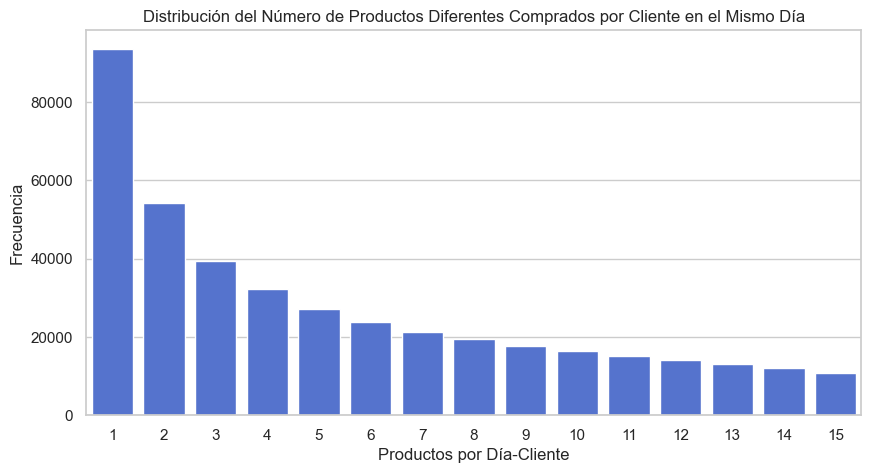

In [11]:
# Graficar distribución de productos por ticket diario
ticket_size = items_por_dia_cliente.select("num_productos").to_series().to_numpy()
plt.figure(figsize=(10, 5))
sns.countplot(x=ticket_size[ticket_size <= 15], color="royalblue")
plt.title("Distribución del Número de Productos Diferentes Comprados por Cliente en el Mismo Día")
plt.xlabel("Productos por Día-Cliente")
plt.ylabel("Frecuencia")
plt.savefig("productos_por_dia.png")
plt.show()


## Conclusión del Notebook y Estrategia de Modelado
1. **Esparsidad de la Matriz**: La esparsidad de la matriz de interacciones cliente-producto es de **98.27%**. Esto confirma la hipótesis de que un modelo de Factorización de Matrices tradicional o reglas heurísticas sufrirá severamente de dispersión. Un modelo Two Towers basado en embeddings continuos es idóneo para generalizar interacciones.
2. **Variables a utilizar para la Torre de Consulta (Query Tower)**:
   - `RUC` (identificador único anonimizado).
   - `CIUDAD` y `RUTA` (variables de contexto geográfico y operativo del cliente).
   - `LATITUD` y `LONGITUD` (coordenadas truncadas del cliente, imputando nulos mediante la latitud/longitud promedio de su respectiva `CIUDAD` o `RUTA`).
3. **Variables a utilizar para la Torre de Candidatos (Candidate Tower)**:
   - `COD_PROD` (identificador de producto).
   - `MARCA` y `CATEGORIA` (extraídas del catálogo, o mapeadas desde el histórico).
   - `precio` y `peso_unitario` (variables continuas de escala).
4. **Estrategia para valores faltantes**:
   - `LATITUD` y `LONGITUD` tienen un 24.96% de valores nulos en transacciones. Imputaremos utilizando el centroide geográfico (promedio) de la `CIUDAD` o `RUTA` correspondiente.
   - `EAN13` presenta un 4.92% de nulos en transacciones y 23.3% en catálogo. Dado su alta cardinalidad y cantidad de nulos, descartaremos el EAN13 para el modelo de recomendación, apoyándonos en `COD_PROD` que es 100% completo.
5. **Generación de Ejemplos Positivos y Negativos**:
   - **Ejemplos Positivos**: Transacciones co-ocurrentes el mismo día por el mismo cliente o dentro de una ventana temporal de 30 días, representando el cross-selling constructivo (ej. cemento + aditivo).
   - **Muestreo de Negativos**: Utilizaremos **In-Batch Negatives** durante el entrenamiento en TensorFlow Recommenders, penalizando la popularidad con corrección LogQ para evitar recomendar solamente los productos más comunes globales.
